# ЗАДАНИЕ
Представим следующую ситуацию: химиками были предоставлены конфиденциальные данные о 1000 химических соединений с указанием их эффективности против вируса гриппа. Параметры, характеризующие эффективность, обозначаются как IC50, CC50 и SI.

Обратите внимание, что значение SI рассчитывается на основе параметров IC50 и CC50. Подробную информацию об этих показателях можно найти в открытых источниках для более глубокого понимания контекста задачи.

Все остальные представленные признаки являются числовыми характеристиками химических соединений.

1. IC50 (Полуингибиторная концентрация)
IC50 (Inhibitory Concentration 50) — это концентрация лекарства, при которой достигается 50% ингибирование биологической активности (например, роста клеток или вирусной репликации).

Диапазон: Обычно измеряется в микромолях (µM) или миллимолях (mM).
Применение: Используется для оценки активности антибактериальных, противовирусных и противораковых препаратов.
Толкование: Чем ниже значение IC50, тем более активно вещество ингибирует целевую молекулу или процесс.

2. CC50 (Цитотоксическая концентрация)
CC50 (Cytotoxic Concentration 50) — это концентрация лекарства, при которой наблюдается 50% клеточная токсичность, то есть 50% клеток погибает.

Диапазон: Также измеряется в μM или mM.
Применение: Используется для оценки токсичности лекарств для нормальных клеток.
Толкование: Меньшее значение CC50 может указывать на более высокую токсичность вещества к клеткам.

3. SI (Соотношение селективности)
SI (Selectivity Index) — это отношение CC50 к IC50 и служит для оценки селективности лекарства относительно целевой клетки или патогена.

SI=CC50/IC50

Применение: Используется, чтобы определить, насколько препарат безопасен по сравнению с его эффективностью. Чем выше SI, тем более селективным считается препарат.
Толкование:
SI > 10: Хорошая селективность (низкая токсичность для нормальных клеток по сравнению с ингибированием патогена).
SI < 1: Указывает на риск токсичности, так как концентрация, убивающая нормальные клетки, близка или ниже концентрации, необходимой для ингибирования целевой молекулы.
Обобщение
IC50: Измеряет, насколько эффективно вещество ингибирует биологическую активность.
CC50: Измеряет токсичность вещества для нормальных клеток.
SI: Оценивает селективность лекарства, сравнивая его токсичность для нормальных клеток с эффективностью против целевой молекулы/патогена.
Эти характеристики помогают исследователям и медикам оценивать эффективность и безопасность новых лекарств. 

## Драфт план действий по ресеч, feature engeneering и  уменьшению размерности

Этап 1. Первичный анализ и предобработка (EDA + Cleaning)

Цель: понять структуру данных

1. Общая проверка:
   · Типы данных, процент пропусков на столбец, наличие дубликатов строк.
   · Разделите признаки на категориальные, бинарные, непрерывные.
   · Проверьте целевые переменныe (SI, IC50, CC50) на выбросы и нормальность распределения (log-преобразование часто нужно для IC50/CC50).
2. Работа с пропусками:
   · Удалить столбцы с >70% пропусков.
   · Для остальных: применить медианную / KNN-импутацию. Для бинарных/категориальных – мода.
3. Выбросы:
   · В признаках: попробовать выполнить оценку  по возможности.

Этап 2. Feature Engineering (создание новых признаков)

Цель: улучшить предсказательную способность.

1. Мультипликативные и линейные комбинации:
   · Можно попробовать создать признаки отношения хим соединений, изучив достаточно домен.
   · Если есть дескрипторы растворимости и липофильности – создайте их произведение или разность.(не смогла углубиться и изучить вопрос)
2. Агрегатные признаки (осторожно, только если есть логика):
   · Для каждого соединения: сумма, среднее, стандартное отклонение по группам однотипных показателей (например, по всем атомным зарядам или по всем топологическим индексам).
3. Трансформации целевых переменных:
   · log_IC50, log_CC50, log_SI. Регрессию лучше  строить на логарифмах.

Этап 3. Отбор признаков (Feature Selection) – “самые нужные”

Цель: сократить 213 → 40-80 ( возможно ) наиболее информативных признаков.

Используем три метода последовательно:

1. Фильтрация по корреляции с целевыми:
   · Рассчитайте для каждого признака корреляцию Пирсона (для линейной связи) или расстояние Спирмена (для нелинейной) с IC50, CC50, SI.
   · Оставьте признаки с корреляцией >0.15 (или >0.1, если их мало). Удалите признаки с корреляцией между собой >0.98 (дубликаты).
2. Встроенные методы (Embedded) – самое важное:
   · Обучите Lasso-регрессию (L1) отдельно для IC50 и CC50 – она занулит неважные признаки. Возьмите те, у которых коэффициент не ноль хотя бы для одной цели.
   · Используйте Random Forest – посмотрите feature_importances_. Возьмите топ-50 признаков.
3. Взаимосвязи (взаимодействия):
   · Проверьте признак * log_IC50 → не надо.
   · Взаимосвязь: вычислите SI = CC50 / IC50 – это определение. Проверьте, не нарушена ли эта формула в ваших данных (если да, то ищите признаки, корректирующие отклонение).

Этап 4. Уменьшение размерности 

Цель: бороться с проклятием размерности и мультиколлинеарностью.

Редукция обычно делается после этапов 2-3, на оставшихся 50-100 признаках. 

1. PCA (Principal Component Analysis) – unsupervised:
   · Стандартизируем  признаки (StandardScaler).
   · Строим PCA,  95% дисперсии (обычно 20-40 компонент).
2. Supervised / Interpretable: (опционально можно попробовать)
   · Анализ канонических корреляций (CCA) – найти линейные комбинации признаков, максимально коррелирующие с SI и IC50 одновременно.
   · Autoencoder (нелинейная редукция) – если данных маловато (1000 записей), не рекомендуется, будет переобучение.

Этап 5. Проверка для регрессии (финальная подготовка)

1. Мультиколлинеарность:
   · Рассчитать VIF (Variance Inflation Factor) для отобранных признаков. Удалить те, где VIF > 10 
2. Нормализация:
   · MinMaxScaler (для нейросетей, SVM) или StandardScaler (для линейной регрессии, Lasso, Ridge).
3. Сплит данных:
   · Стратифицированный сплит (не по цели, а по квантилям SI) – чтобы в тренировке и тесте было покрытие всех значений.

Итоговая схема обработки (коротко) - которой можно придерживаться, но это не строгий мой план, скорее драфт

1. Drop columns (>70% NA)
2. Медианная импутация
3. Log1p для скошенных признаков и целей
4. Lasso на IC50 и CC50 → отобрать ненулевые признаки
5. Из них Random Forest importance → топ-30-50
6. Если VIF высок – заменить топ-коррелированную группу на PCA компоненту
7. Итог: матрица [1000, ~30-40] фичей для модели регрессии


In [ ]:

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate
import seaborn as sns
from scipy import stats

from sklearn.feature_selection import SelectKBest, f_classif
from skfeature.function.similarity_based import fisher_score
from sklearn.datasets import make_regression
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE


In [7]:

drugs = pd.read_excel("datadrug.xlsx")
drugs

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,996,31.000104,34.999650,1.129017,12.934891,12.934891,0.048029,-0.476142,0.382752,49.133333,...,0,0,0,0,0,0,0,0,0,0
997,997,31.999934,33.999415,1.062484,13.635345,13.635345,0.030329,-0.699355,0.369425,44.542857,...,0,0,0,0,0,0,0,0,0,0
998,998,30.999883,33.999458,1.096761,13.991690,13.991690,0.026535,-0.650790,0.284923,41.973684,...,1,0,0,0,0,0,0,0,0,0
999,999,31.998959,32.999644,1.031272,13.830180,13.830180,0.146522,-1.408652,0.381559,39.000000,...,0,0,0,0,0,0,0,0,0,0


In [8]:
drugs.describe()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000
mean,500.000000,222.805156,589.110728,72.508823,10.831637,10.831637,0.180681,-0.967237,0.580412,29.487989,...,0.053946,0.011988,0.008991,0.000999,0.000999,0.051948,0.0,0.069930,0.204795,0.006993
std,289.108111,402.169734,642.867508,684.482739,3.307505,3.307505,0.168710,1.588036,0.212230,12.742749,...,0.259011,0.108886,0.094441,0.031607,0.031607,0.222033,0.0,0.255157,1.215326,0.083373
min,0.000000,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,250.000000,12.515396,99.999036,1.433333,9.252350,9.252350,0.051073,-1.334487,0.442842,18.486486,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,500.000000,46.585183,411.039342,3.846154,12.179236,12.179236,0.124606,-0.419485,0.634981,29.290323,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,750.000000,224.975928,894.089176,16.566667,13.167843,13.167843,0.291020,0.061754,0.742483,38.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,1000.000000,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


In [9]:
# Вывод типов данных по колонкам
# Изменение параметров отображения для показа всех колонок
pd.set_option('display.max_columns', None)  # Отображение всех колонок
pd.set_option('display.expand_frame_repr', False)  # Запрет на перенос DataFrame

pd.set_option('display.max_rows', None)  # Отображение всех строк
drugs.dtypes

Unnamed: 0                    int64
IC50, mM                    float64
CC50, mM                    float64
SI                          float64
MaxAbsEStateIndex           float64
MaxEStateIndex              float64
MinAbsEStateIndex           float64
MinEStateIndex              float64
qed                         float64
SPS                         float64
MolWt                       float64
HeavyAtomMolWt              float64
ExactMolWt                  float64
NumValenceElectrons           int64
NumRadicalElectrons           int64
MaxPartialCharge            float64
MinPartialCharge            float64
MaxAbsPartialCharge         float64
MinAbsPartialCharge         float64
FpDensityMorgan1            float64
FpDensityMorgan2            float64
FpDensityMorgan3            float64
BCUT2D_MWHI                 float64
BCUT2D_MWLOW                float64
BCUT2D_CHGHI                float64
BCUT2D_CHGLO                float64
BCUT2D_LOGPHI               float64
BCUT2D_LOGPLOW              

In [10]:
#выполним  лог преобразование для столбцов IC50&CC50
# Выполнение логарифмического преобразования
drugs['IC50, mM'] = np.log(drugs['IC50, mM'])
drugs['CC50, mM'] = np.log(drugs['CC50, mM'])
drugs['SI'] = np.log(drugs['SI'])


In [11]:
drugs[['IC50, mM', 'CC50, mM','SI']].describe()


,"IC50, mM","CC50, mM",SI
count,1001.000000,1001.000000,1001.000000
mean,3.830792,5.541732,1.710940
std,2.166162,1.647983,1.735183
min,-5.650234,-0.355521,-4.466342
25%,2.526960,4.605161,0.360003
50%,3.841283,6.018689,1.347074
75%,5.415993,6.795806,2.807393
max,8.325677,8.420457,9.656346


In [ ]:


def analyze_missing(df):
    """Анализ пропусков"""
    missing =df.isnull().sum()
    missing_pct = 100 * missing / len(df)
    
    # Таблица с долей пропусков
    missing_df = pd.DataFrame({
        'Кол-во пропусков': missing,
        'Доля %': missing_pct
    }).sort_values('Доля %', ascending=False)
    
    print("=== Анализ пропусков ===\n")
    print(missing_df[missing_df['Доля %'] > 0])
    
    # Смотрим
    plt.figure(figsize=(12, 4))
    plt.bar(missing_df.index[:10], missing_df['Доля %'][:10])
    plt.xticks(rotation=45)
    plt.ylabel('Доля пропусков (%)')
    plt.title('Топ-10 признаков с пропусками')
    plt.tight_layout()
    plt.show()
    
    return missing_df

def detect_missing_patterns(df, threshold_sec=2, sampling_rate=50):
    #Детектируем паттерны пропусков 
    results = {}

    for col in df.columns:
        if df[col].isnull().sum() == 0:
            continue
        

        # серии последовательных пропусков
        missing_mask = df[col].isnull().astype(int)
        changes = missing_mask.diff().fillna(0)
        starts = np.where(changes == 1)[0]
        ends = np.where(changes == -1)[0]
        
        if len(starts) == 0 and missing_mask.iloc[0] == 1:
            starts = [0]
        if len(ends) == 0 and missing_mask.iloc[-1] == 1:
            ends = [len(df)]
            
        lengths = ends - starts
        max_gap_sec = max(lengths) / sampling_rate
        
        results[col] = {
            'total_missing': missing_mask.sum(),
            'num_gaps': len(lengths),
            'avg_gap_samples': np.mean(lengths),
            'max_gap_sec': max_gap_sec,
            'is_block_missing': max_gap_sec > threshold_sec
        }

    return pd.DataFrame(results).T

=== Анализ пропусков ===

                     Кол-во пропусков  Доля %
MaxAbsPartialCharge                 3  0.2997
MinAbsPartialCharge                 3  0.2997
MaxPartialCharge                    3  0.2997
MinPartialCharge                    3  0.2997
BCUT2D_MWLOW                        3  0.2997
BCUT2D_MWHI                         3  0.2997
BCUT2D_MRLOW                        3  0.2997
BCUT2D_MRHI                         3  0.2997
BCUT2D_LOGPLOW                      3  0.2997
BCUT2D_LOGPHI                       3  0.2997
BCUT2D_CHGLO                        3  0.2997
BCUT2D_CHGHI                        3  0.2997


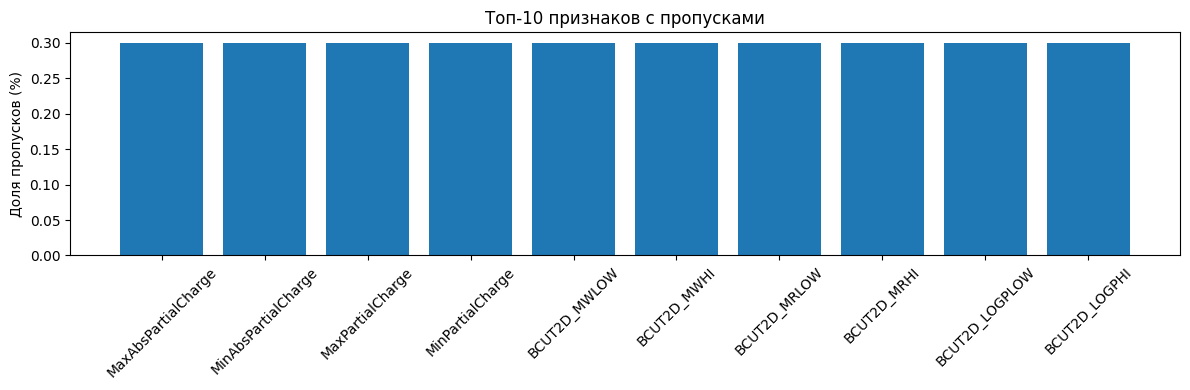

,Кол-во пропусков,Доля %
MaxAbsPartialCharge,3,0.2997
MinAbsPartialCharge,3,0.2997
MaxPartialCharge,3,0.2997
MinPartialCharge,3,0.2997
BCUT2D_MWLOW,3,0.2997
BCUT2D_MWHI,3,0.2997
BCUT2D_MRLOW,3,0.2997
BCUT2D_MRHI,3,0.2997
BCUT2D_LOGPLOW,3,0.2997
BCUT2D_LOGPHI,3,0.2997


In [14]:
analyze_missing(drugs)

In [13]:
# Получение строк с пропусками
rows_with_nan = drugs[drugs.isna().any(axis=1)] 

# Вывод строк с пропусками
rows_with_nan
#строки  можно заполнить медианным значением 

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
78,78,7.027399,7.027399,0.000000,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,266.174,263.150,265.983418,84,0,NaN,NaN,NaN,NaN,1.470588,2.117647,2.647059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.679515,2.893801,706.229055,12.740122,8.724523,11.541020,7.913591,4.234380,6.686885,3.069781,5.190391,1.918500,3.205657,1.191889,2.077612,-1.17,7296.319551,12.291220,4.251446,2.012276,113.132727,0.0,0.0,0.0,0.0,0.0,113.560901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.132210,50.640050,0.0,21.908314,0.0,5.156436,6.255769,20.468122,0,0.0,5.559267,5.817863,0.0,0.000000,65.541257,10.799569,10.114318,0.0,9.950974,0.0,5.777654,0,125.29,27.100010,19.117754,0.0,39.179054,0.000000,4.515398,8.467343,0.000000,0.0,15.181342,0.0,13.089387,0.278462,25.148358,17.703941,-0.984907,-0.774720,0.0,1.345753,0.0,-1.472941,0.2,17,0,10,0,0,0,0,2,2,9,0,12,2,0,0,0,2,-2.1368,55.1808,0,0,0,0,0,5,0,0,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
79,79,3.225724,7.538224,4.312501,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,266.174,263.150,265.983418,84,0,NaN,NaN,NaN,NaN,1.470588,2.117647,2.647059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.679515,2.893801,706.229055,12.740122,8.724523,11.541020,7.913591,4.234380,6.686885,3.069781,5.190391,1.918500,3.205657,1.191889,2.077612,-1.17,7296.319551,12.291220,4.251446,2.012276,113.132727,0.0,0.0,0.0,0.0,0.0,113.560901,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9

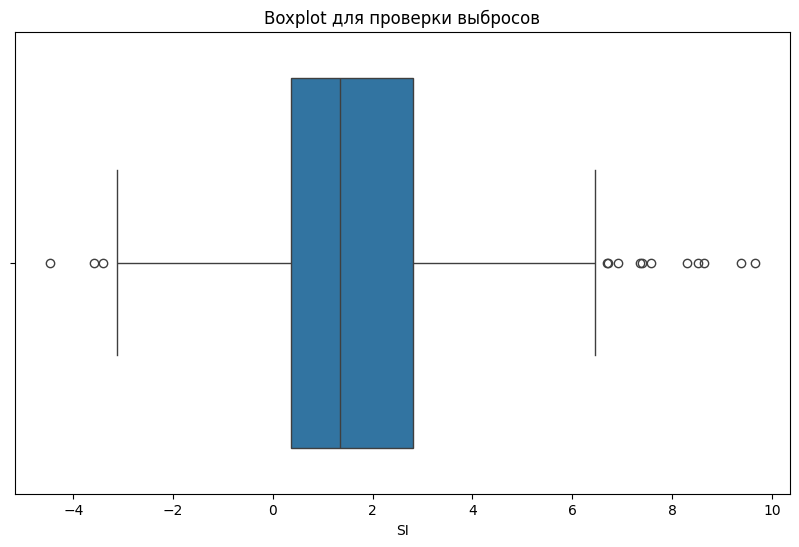

Выбросы:
     Unnamed: 0  IC50, mM  CC50, mM        SI  MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex       qed        SPS    MolWt  HeavyAtomMolWt  ExactMolWt  NumValenceElectrons  NumRadicalElectrons  MaxPartialCharge  MinPartialCharge  MaxAbsPartialCharge  MinAbsPartialCharge  FpDensityMorgan1  FpDensityMorgan2  FpDensityMorgan3  BCUT2D_MWHI  BCUT2D_MWLOW  BCUT2D_CHGHI  BCUT2D_CHGLO  BCUT2D_LOGPHI  BCUT2D_LOGPLOW  BCUT2D_MRHI  BCUT2D_MRLOW    AvgIpc  BalabanJ     BertzCT       Chi0      Chi0n      Chi0v       Chi1     Chi1n     Chi1v     Chi2n     Chi2v     Chi3n     Chi3v     Chi4n     Chi4v  HallKierAlpha            Ipc     Kappa1    Kappa2    Kappa3   LabuteASA  PEOE_VSA1  PEOE_VSA10  PEOE_VSA11  PEOE_VSA12  PEOE_VSA13  PEOE_VSA14  PEOE_VSA2  PEOE_VSA3  PEOE_VSA4  PEOE_VSA5  PEOE_VSA6  PEOE_VSA7  PEOE_VSA8  PEOE_VSA9   SMR_VSA1  SMR_VSA10  SMR_VSA2   SMR_VSA3   SMR_VSA4   SMR_VSA5   SMR_VSA6   SMR_VSA7  SMR_VSA8  SMR_VSA9  SlogP_VSA1  SlogP_VSA10  SlogP_VSA

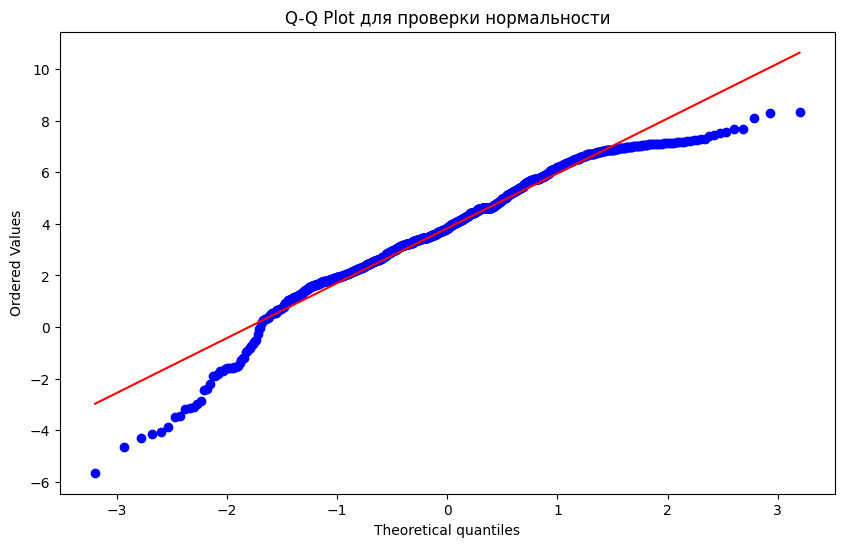

In [ ]:

# Проверка выбросов с помощью Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=drugs['SI'])
plt.title('Boxplot для проверки выбросов')
plt.show()

# Статистическая проверка выбросов с использованием квантилей 
Q1 = drugs['IC50, mM'].quantile(0.25)
Q3 = drugs['IC50, mM'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = drugs[(drugs['IC50, mM'] < lower_bound) | (drugs['IC50, mM'] > upper_bound)]
print(f"Выбросы:\n{outliers}")

# Проверка нормальности распределения с помощью теста Шапиро-Уилка
shapiro_test = stats.shapiro(drugs['IC50, mM'])
print(f"Тест Шапиро-Уилка: статистика={shapiro_test.statistic}, p-value={shapiro_test.pvalue}")

# Визуализация нормальности распределения с помощью Q-Q графика
plt.figure(figsize=(10, 6))
stats.probplot(drugs['IC50, mM'], dist="norm", plot=plt)
plt.title('Q-Q Plot для проверки нормальности')
plt.show()

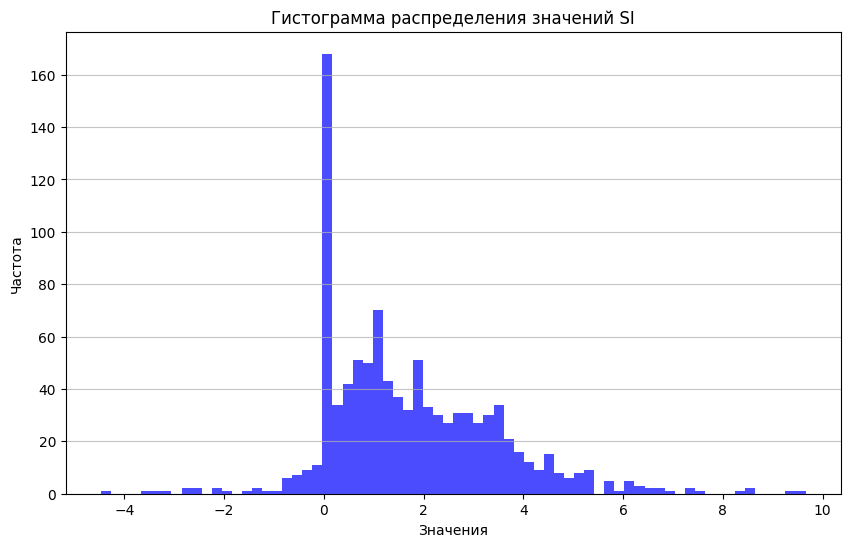

In [15]:
# Распределение значений ( смотрим на нормальность или скошенность)
plt.figure(figsize=(10, 6))
plt.hist(drugs['SI'], bins=70, color='blue', alpha=0.7)
plt.title('Гистограмма распределения значений SI')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()

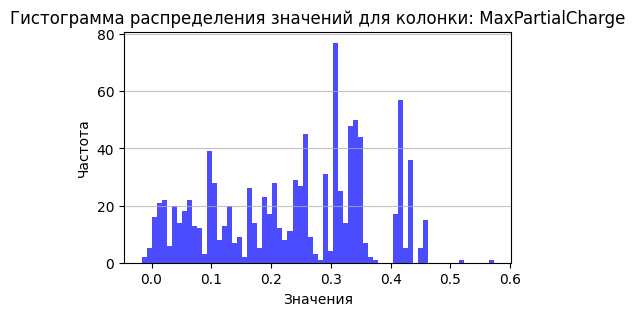

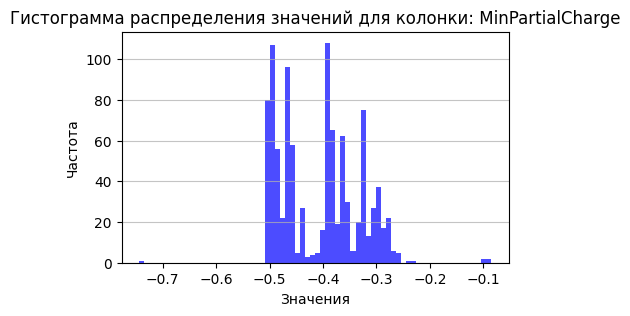

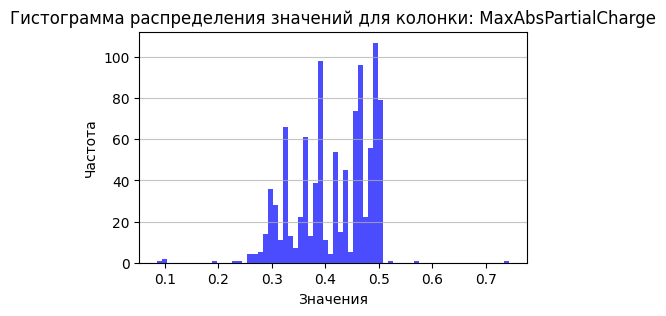

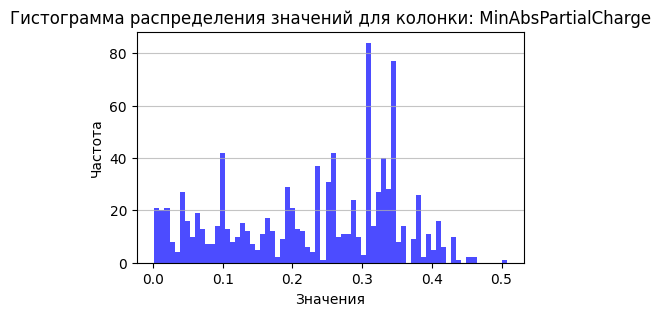

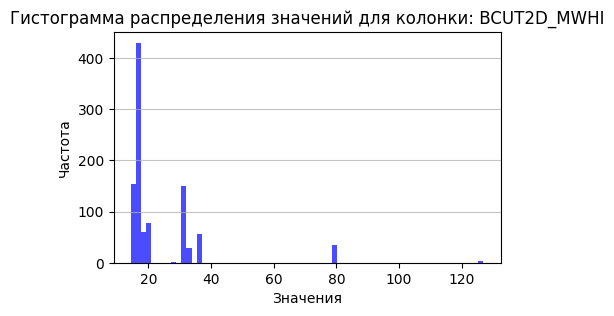

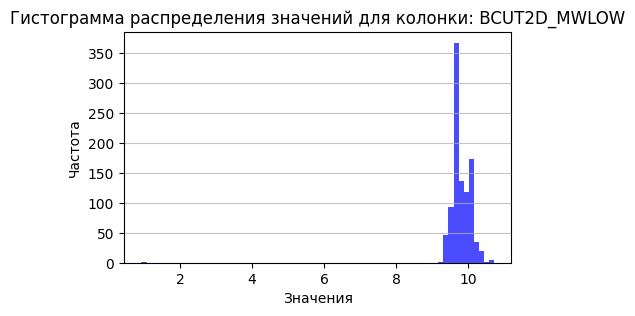

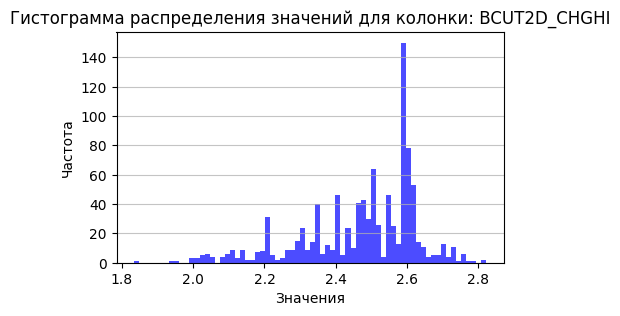

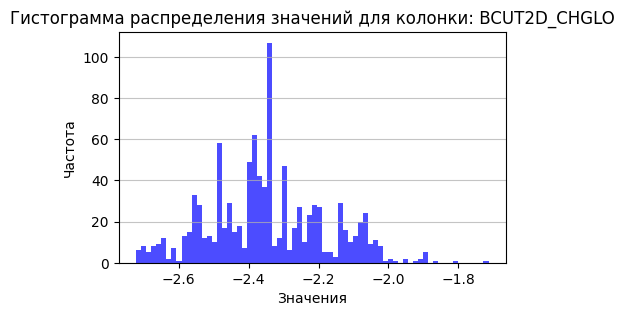

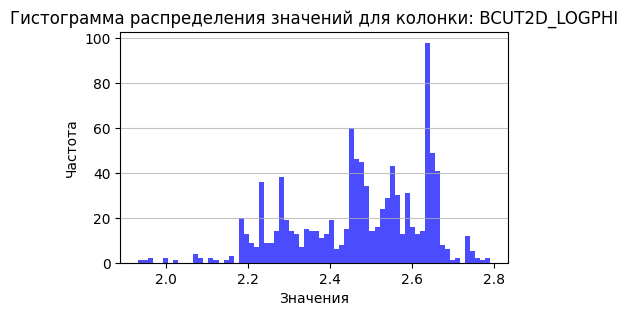

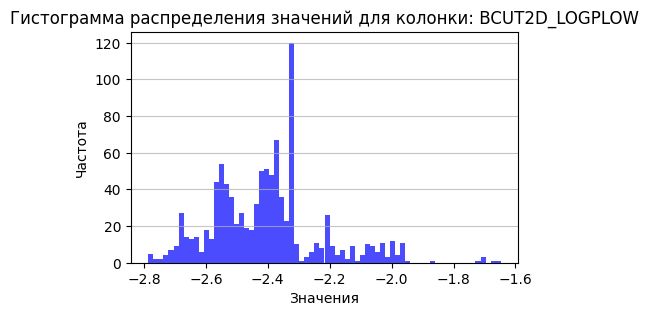

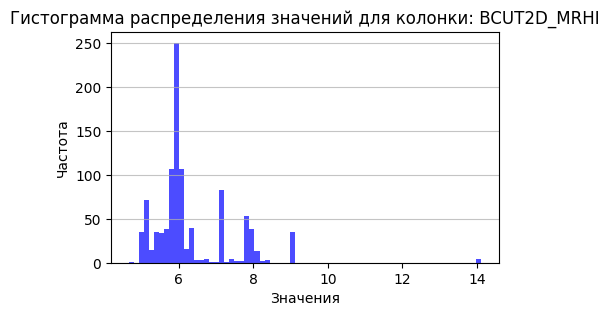

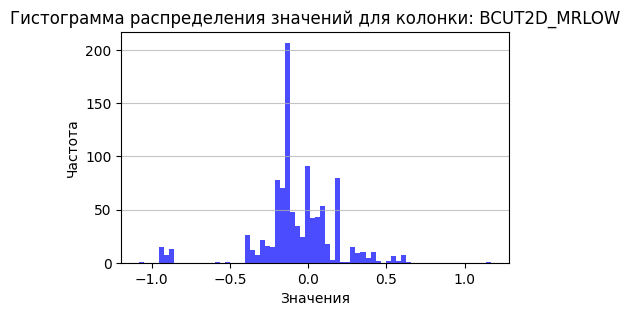

In [54]:
# Оцениваем колонки с пропусками
columns_with_nan = drugs.columns[drugs.isnull().any()]

# Построение гистограмм для колонок с пропусками
for column in columns_with_nan:
    plt.figure(figsize=(5, 3))
    plt.hist(drugs[column], bins=70, color='blue', alpha=0.7)
    plt.title(f'Гистограмма распределения значений для колонки: {column}')
    plt.xlabel('Значения')
    plt.ylabel('Частота')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [16]:
#clear_drugs = drugs.dropna()
# Заполним пропуски используя SimpleImputer

from sklearn.impute import SimpleImputer

# Создадим экземпляр SimpleImputer с медианным методом, он подходит с учетом того, что наши данные распределены ненормально
imputer = SimpleImputer(strategy='median')

# Применим
drugs_fin = pd.DataFrame(imputer.fit_transform(drugs), columns=drugs.columns)

drugs_fin[drugs_fin.isna().any(axis=1)] 


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea


In [17]:
#удалим однозначно не нужный столбец с идентификаторами измерений "Unnamed: 0"
#drugs_fin[drugs_fin.isna().any(axis=1)] 
drugs_fin = drugs_fin.drop(columns=['Unnamed: 0'])

In [18]:
drugs_fin.shape

(1001, 213)

In [19]:
#проверка на дубликаты
dupe_mask = drugs_fin.duplicated(keep=False)
duplicates = drugs_fin[dupe_mask]
print(len(duplicates))
duplicates.head(20)   

57


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
83,4.426274,7.837521,3.411248,8.848320,8.848320,0.261583,0.261583,0.722639,44.571429,197.322,174.138,197.177964,82.0,0.0,0.055554,-0.395054,0.395054,0.055554,1.357143,2.071429,2.500000,16.251035,9.689596,2.603648,-2.392008,2.647810,-2.448084,5.123570,0.117741,2.460062,2.106527,226.361619,10.397341,9.637448,9.637448,6.521004,5.864105,5.864105,5.840772,5.840772,5.296572,5.296572,3.751163,3.751163,-0.08,1754.024111,10.438224,3.208431,1.165663,87.086048,10.423316,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,20.771212,36.010352,12.586597,6.606882,5.106527,0.000000,0.0,5.316789,16.747887,46.075517,13.151638,0.000000,0.0,0.000000,5.316789,0.000000,0.000000,0.000000,24.300007,0.000000,16.747887,40.033676,0.000000,0.0,0.000000,0.0,32.26,0.000000,0.000000,0.0,6.606882,16.871822,12.462662,19.262465,0.000000,0.0,26.088000,5.106527,0.000000,0.000000,0.000000,12.357139,0.937459,0.892308,0.628148,4.067527,8.284085,0.000000,1.000000,14.0,2.0,2.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,2.0,2.0,3.0,2.0,0.0,2.0,2.0,1.7831,58.1055,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84,4.426274,7.837521,3.411248,8.848320,8.848320,0.261583,0.261583,0.722639,44.571429,197.322,174.138,197.177964,8

In [20]:
#удалим  дубликаты 
drugs_fin = drugs_fin.drop_duplicates(keep='first').reset_index(drop=True)
drugs_fin.shape

(969, 213)

In [21]:
# Проверим и колонки на дублирующиеся 
cols = drugs_fin.columns
# все дубликаты (включая повторяющиеся имена)
duplmask = pd.Series(cols).duplicated(keep=False)
duplicates = pd.Series(cols)[duplmask].tolist()

print("дубликаты" , len(duplicates)>0)
print("Список дублей", duplicates)

дубликаты False
Список дублей []


In [22]:
#сохраним очищенный датасет
drugs_fin.to_csv('drugs_fin_clean.csv', index=False, encoding='utf-8')

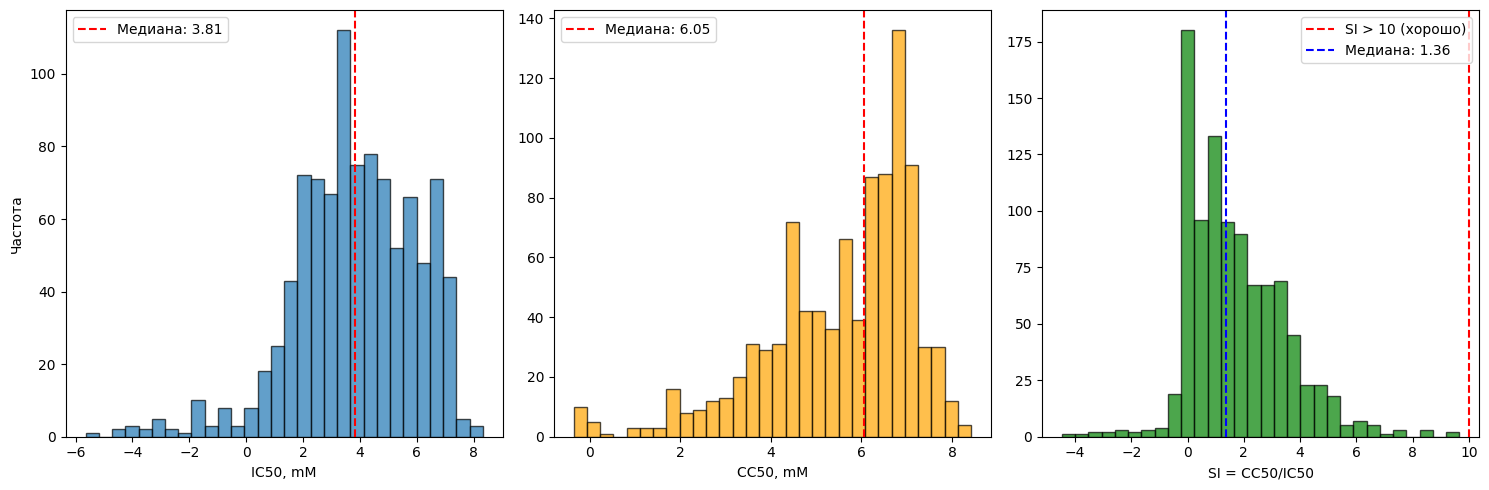

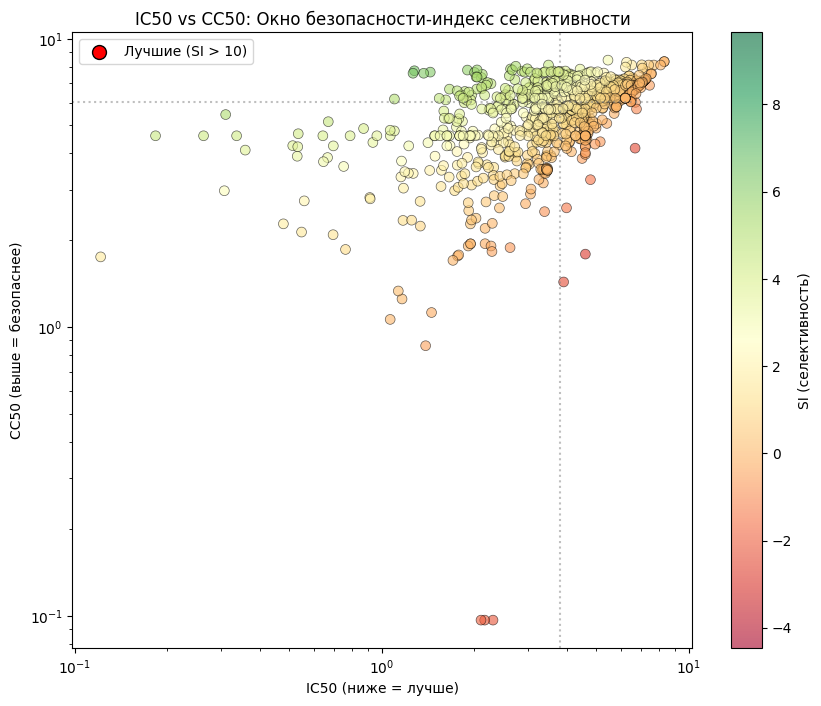

In [23]:
#  Гистограммы IC50, CC50, SI 'SI','IC50, mM','CC50, mM'
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(drugs_fin['IC50, mM'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(drugs_fin['IC50, mM'].median(), color='red', linestyle='--', label=f'Медиана: {drugs_fin["IC50, mM"].median():.2f}')
axes[0].set_xlabel('IC50, mM')
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].hist(drugs_fin['CC50, mM'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1].axvline(drugs_fin['CC50, mM'].median(), color='red', linestyle='--', label=f'Медиана: {drugs_fin["CC50, mM"].median():.2f}')
axes[1].set_xlabel('CC50, mM')
axes[1].legend()

axes[2].hist(drugs_fin['SI'], bins=30, color='green', edgecolor='black', alpha=0.7)
axes[2].axvline(10, color='red', linestyle='--', label='SI > 10 (хорошо)')
axes[2].axvline(drugs_fin['SI'].median(), color='blue', linestyle='--', label=f'Медиана: {drugs_fin["SI"].median():.2f}')
axes[2].set_xlabel('SI = CC50/IC50')
axes[2].legend()

plt.tight_layout()
plt.show()

#Scatter plot IC50 vs CC50 по SI
plt.figure(figsize=(10, 8))
sc = plt.scatter(drugs_fin['IC50, mM'], drugs_fin['CC50, mM'], c=drugs_fin['SI'], 
                 cmap='RdYlGn', alpha=0.6, edgecolors='black', linewidth=0.5, s=50)
plt.xlabel('IC50 (ниже = лучше)')
plt.ylabel('CC50 (выше = безопаснее)')
plt.xscale('log')
plt.yscale('log')
plt.colorbar(sc, label='SI (селективность)')
plt.axhline(y=drugs_fin['CC50, mM'].median(), color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=drugs_fin['IC50, mM'].median(), color='gray', linestyle=':', alpha=0.5)

# Выделяем лучшие соединения (SI > 10)
top_compounds = drugs_fin[drugs_fin['SI'] > 10]
plt.scatter(top_compounds['IC50, mM'], top_compounds['CC50, mM'], 
            c='red', s=100, edgecolors='black', 
            label=f'Лучшие (SI > 10)')
plt.legend()
plt.title('IC50 vs CC50: Окно безопасности-индекс селективности')
plt.show()

In [24]:
drugs_fin[drugs_fin['SI'] > 8]

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
105,-0.933722,7.583471,8.517193,12.006373,12.006373,0.044375,-0.044375,0.571047,37.888889,254.394,226.170,254.211456,104.0,0.0,0.361553,-0.457603,0.457603,0.361553,1.277778,1.888889,2.277778,16.546170,9.697377,2.624439,-2.382344,2.657151,-2.437245,5.705250,-0.862420,2.469159,2.029563,355.995327,13.767585,12.746838,12.746838,8.061297,7.061021,7.061021,8.037395,8.037395,5.591093,5.591093,3.891710,3.891710,-0.57,7017.348786,13.852299,3.959867,2.066546,111.081651,9.219894,6.103966,6.544756,0.00000,0.0,5.969305,0.000000,4.794537,0.0,0.0,20.771212,30.595361,5.414990,21.143016,14.014431,5.969305,0.0,0.000000,16.747887,46.137643,27.687772,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,44.244075,9.531400,16.747887,40.033676,0.000000,0.0,0.0,0.0,26.30,0.000000,4.794537,0.0,17.488262,16.442778,12.338728,12.841643,0.000000,21.143016,20.771212,4.736863,6.439364,0.0,12.006373,0.000000,0.492805,0.681946,0.000000,3.691668,7.456562,6.064615,0.933333,18.0,0.0,3.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,3.0,3.0,2.0,0.0,2.0,2.0,2.4506,72.0084,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
751,-5.650234,2.995704,8.645938,11.284112,11.284112,0.021160,-0.986230,0.669590,26.250000,284.356,260.164,284.173607,114.0,0.0,0.330

**Методы Feature Engineering (создание новых признаков) не буду рассматривать, так как  это довольно трудоемкий процесс в рамках решения курсовой не смогу охватить контекст (домен) профиля и погрузиться в значение всех признаков для нахождения  возможных связей  и последующей агрегации их, попробую состредоточиться на методах  Feature Engineering - отбор важных признаков**

# Feature Selection

**Выделение или отбор признаков (Feature selection)** – это процедура отбрасывания незначащих переменных из очищенной выборки перед запуском машинного обучения и интеллектуального анализа данных (Data Mining). Сокращение числа предикторов необходимо по нескольким причинам:

- **значимость признаков** – как правило, исходная выборка всегда содержит много «мусорных данных»: шумов, выбросов, а на реальный результат влияют лишь несколько предикторов;
- **точность решения** – некоторые модели Machine Learning чувствительны к величине входного вектора. Например, у нейросетей большое число входных данных может привести к переобучению. Меньше вводящих в заблуждение данных означает повышение точности моделирования.;
- **скорость вычислений** – чем меньше переменных, тем быстрее будут идти расчеты.

**Методы отбора признаков принято делить на несколько категорий:**

1. Методы фильтрации (filter methods)
2. Оберточные методы (wrapper methods)
3. Встроенные методы (embedded methods)

## Методы фильтрации (filter methods)

`mutual_info_classif` — это функция из библиотеки `sklearn.feature_selection`, которая вычисляет взаимную информацию между признаками и целевой переменной. Она помогает понять, насколько информация одного признака уменьшает неопределенность относительно целевой переменной.

Взаимная информация показывает нелинейные зависимости, что делает её более мощным инструментом, чем, например, простая корреляция.

**Взаимная информация (Mutual Information, MI)** — это мера, которая показывает, сколько информации один признак содержит о целевой переменной.

Если $X$ — это признак, а $Y$ — целевая переменная, то взаимная информация между ними определяется как:

$$MI(X,Y)=H(Y)−H(Y∣X)$$

где:
- $H(Y)$ — энтропия целевой переменной
- $Y$ (измеряет неопределенность).
- $H(Y∣X)$ — условная энтропия $Y$, если известен $X$.

____
- Если $MI(X, Y) = 0$, значит, признак $X$ не содержит информации о целевой переменной $Y$.
- Если $MI(X, Y) > 0$, значит, признак полезен для предсказания $Y$.

In [350]:
from sklearn.feature_selection import mutual_info_regression

X = drugs_fin.drop(columns=['SI']) # удаляем так же из даты  связанные  признаки  
y = drugs_fin['SI']


# Вычисление взаимной информации для регрессии
mi = mutual_info_regression(X, y)

# Создание df для отображения результатов
mi_df = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mi})
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

# Вывод 
print(mi_df)

# Визуализация взаимной информации
#plt.figure(figsize=(10, 15))
#plt.barh(mi_df['Feature'], mi_df['Mutual Information'], color='skyblue')
#plt.xlabel('Mutual Information')
#plt.title('Взаимная информация между признаками и целевой переменной')
#plt.show()

# Отбор признаков (например, выбираем признаки с взаимной информацией > 0.1)
selected_features_mi = mi_df[mi_df['Mutual Information'] > 0.1]['Feature']
print(f"Отобранные признаки: { selected_features_mi.count(),selected_features_mi.tolist()}")

             Feature  Mutual Information
0           IC50, mM            0.623097
1           CC50, mM            0.272154
24     BCUT2D_LOGPHI            0.209660
23      BCUT2D_CHGLO            0.202026
67          SMR_VSA4            0.192197
..               ...                 ...
199  fr_prisulfonamd            0.000000
206     fr_tetrazole            0.000000
204       fr_sulfone            0.000000
208      fr_thiocyan            0.000000
211          fr_urea            0.000000

[212 rows x 2 columns]
Отобранные признаки: (np.int64(51), ['IC50, mM', 'CC50, mM', 'BCUT2D_LOGPHI', 'BCUT2D_CHGLO', 'SMR_VSA4', 'MaxAbsPartialCharge', 'BCUT2D_LOGPLOW', 'BCUT2D_CHGHI', 'SlogP_VSA5', 'BCUT2D_MRLOW', 'BCUT2D_MWLOW', 'AvgIpc', 'MinPartialCharge', 'SlogP_VSA4', 'MaxEStateIndex', 'MaxAbsEStateIndex', 'FractionCSP3', 'SMR_VSA5', 'MaxPartialCharge', 'BCUT2D_MRHI', 'NumAliphaticRings', 'SlogP_VSA2', 'FpDensityMorgan3', 'PEOE_VSA2', 'VSA_EState8', 'SlogP_VSA6', 'Chi1n', 'VSA_EState7', 'MolLogP

In [354]:
scaler_mi = StandardScaler()
X_mi_scaled = scaler_mi.fit_transform(X)

mi_scores = mutual_info_regression(X_mi_scaled, y, random_state=42)
mi_dfv2 = pd.DataFrame({
    'feature2': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print(f"Топ-15 признаков по Mutual Information:")
print(mi_df.head(30).to_string(index=False))

# Выбираем топ-K признаков по MI
mi_threshold = np.percentile(mi_scores, 75)  # топ 25%
selected_mi = mi_dfv2[mi_dfv2['mi_score'] > mi_threshold]['feature2'].tolist()
print(f"\nОтобрано признаков по MI: {len(selected_mi)}")

Топ-15 признаков по Mutual Information:
            Feature  Mutual Information
           IC50, mM            0.623097
           CC50, mM            0.272154
      BCUT2D_LOGPHI            0.209660
       BCUT2D_CHGLO            0.202026
           SMR_VSA4            0.192197
MaxAbsPartialCharge            0.185658
     BCUT2D_LOGPLOW            0.176130
       BCUT2D_CHGHI            0.171719
         SlogP_VSA5            0.169957
       BCUT2D_MRLOW            0.166032
       BCUT2D_MWLOW            0.162836
             AvgIpc            0.153883
   MinPartialCharge            0.149750
         SlogP_VSA4            0.146826
     MaxEStateIndex            0.146598
  MaxAbsEStateIndex            0.145978
       FractionCSP3            0.143109
           SMR_VSA5            0.141643
   MaxPartialCharge            0.137891
        BCUT2D_MRHI            0.133247
  NumAliphaticRings            0.131959
         SlogP_VSA2            0.130377
   FpDensityMorgan3            0.128837


In [330]:
#сохраним отобранные признаки по методу фильтрации взаимной информации
pd.Series(selected_features_mi).to_csv('selected_features_MutRegr.csv', index=False)

In [331]:
#сохраним отобранные признаки по методу фильтрации взаимной информации
pd.Series(selected_mi).to_csv('selected_features_MutRegrv2.csv', index=False)


In [333]:
#корреляции Пирсона и Спирмена
#drugs_corr = drugs_fin.drop(columns=['IC50, mM','CC50, mM'])

correlation_matrix = drugs_fin.corr(method='pearson')  # Для линейной зависимости
spearman_correlation_matrix = drugs_fin.corr(method='spearman')  # Для нелинейной зависимости

# Вывод корреляций с целевыми переменными
print("Корреляции Спирмена с целевыми переменными:")
print(spearman_correlation_matrix[['SI','IC50, mM','CC50, mM']])
#print(correlation_matrix['SI'])

# Фильтрация по корреляции с целевыми переменными
#target_correlations = spearman_correlation_matrix[['SI','IC50, mM','CC50, mM']].abs()
#selected_features = target_correlations[target_correlations >= 0.3].sort_values(ascending=False)

target_correlations = spearman_correlation_matrix['SI'].abs()
selected_features = target_correlations[(target_correlations > 1.15) | (target_correlations > 1.0)]

# Удаление дубликатов (признаки с высокой корреляцией друг с другом)

high_corr_pairs = set()
for i in range(len(spearman_correlation_matrix.columns)):
    for j in range(i):
        if abs(spearman_correlation_matrix.iloc[i, j]) > 0.90:
            colname = spearman_correlation_matrix.columns[i]
            high_corr_pairs.add(colname)



# Отбор уникальных признаков, которые надо оставить
features_to_drop = list(high_corr_pairs)

# Удаление признаков
final_features = spearman_correlation_matrix.columns.difference(features_to_drop)

print(f"Оставшиеся признаки:  {final_features.shape, final_features.tolist()}")

Корреляции Спирмена с целевыми переменными:
                         SI  IC50, mM  CC50, mM
IC50, mM          -0.640682  1.000000  0.621869
CC50, mM           0.097950  0.621869  1.000000
SI                 1.000000 -0.640682  0.097950
MaxAbsEStateIndex -0.211494  0.114894 -0.118501
MaxEStateIndex    -0.211494  0.114894 -0.118501
...                     ...       ...       ...
fr_thiazole        0.038717 -0.010674 -0.049507
fr_thiocyan             NaN       NaN       NaN
fr_thiophene      -0.035616  0.074987  0.010247
fr_unbrch_alkane   0.095043 -0.071345  0.038847
fr_urea            0.025969  0.042040  0.098891

[213 rows x 3 columns]
Оставшиеся признаки:  ((169,), ['AvgIpc', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BalabanJ', 'CC50, mM', 'EState_VSA1', 'EState_VSA10', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_V

In [334]:
#сохраним  набор признаков по корреляции Спирмена
pd.Series(final_features).to_csv('selected_features_Spearman.csv', index=False)


**Критерий Фишера (F-тест)**

Критерий Фишера – один из наиболее широко используемых методов контролируемого выбора признаков. Алгоритм, который мы будем использовать, возвращает ранги переменных на основе оценки критерия в порядке убывания, после чего уже следует их отбор.

Порог (квантиль 0.25): 52.25
Выбрано признаков: 157
Series([], Name: SI, dtype: float64)


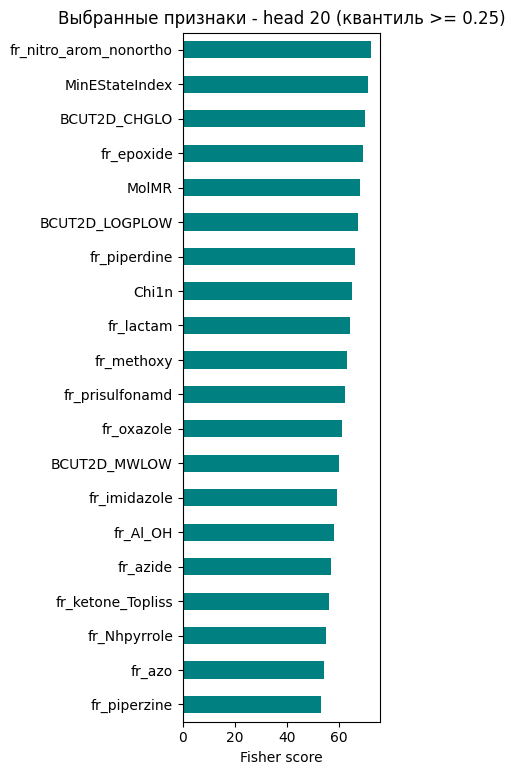

In [339]:

# удаляем не только таргет, но и 'IC50, mM','CC50, mM', так как отбор делаем по SI
X = drugs_fin.drop(columns=['SI','IC50, mM','CC50, mM'])
y = drugs_fin['SI']

# Вычисляем Fisher score
ranks = fisher_score.fisher_score(X.to_numpy(), y.to_numpy())

# Собираем и сортируем по убыванию значимости
feature_importances = pd.Series(ranks, index=X.columns).sort_values(ascending=False)

# Порог по квантилю 
quantile_level = 0.25  # верхние 25%,  оставим пока  75 
threshold = feature_importances.quantile(quantile_level)
selected_featuresF = feature_importances[feature_importances >= threshold]

print(f'Порог (квантиль {quantile_level}): {threshold}')
print(f'Выбрано признаков: {selected_featuresF.shape[0]}')
print(selected_features)


# Визуализация:  выбранные признаки
plt.figure(figsize=(4, max(0.6, 0.05 * selected_featuresF.shape[0])))
selected_featuresF.sort_values().head(20).plot(kind='barh', color='teal')
plt.title(f'Выбранные признаки - head 20 (квантиль >= {quantile_level})')
plt.xlabel('Fisher score')
plt.tight_layout()
plt.show()

# Получение X_selected для дальнейшей работы
X_selected = X[selected_featuresF.index]

## Оберточные методы (wrapper methods)

Оберточные методы (wrapper methods) – поисковые алгоритмы, которые рассматривают предикторы как входы, а эффективность модели как выходы, которые должны быть оптимизированы. Классификатор запускается на разных подмножествах признаков исходной тренировочной выборки. В этой категории есть 2 подхода: включение (forward selection) и исключение (backwards selection) предикторов. Методы включения начинают с пустого подмножества, куда постепенно добавляются разные признаки. В случае исключения метод стартует с исходного множества признаков, постепенно удаляя из него переменные и пересчитывая классификатор. Далее выбирается подмножество признаков с наилучшими параметрами на обучающей выборке и тестируется на контрольном (тестовом) датасете. Есть много способов перебора предикторов: рекурсивное удаление и добавление, генетические алгоритмы, имитация отжига и т.д.. Оберточные методы отслеживают взаимосвязи между признаками, однако они требуют большего количества времени, чем фильтрация.

**Существующие стратегии отбора:**

- Прямой отбор (Forward selection): начинаем с пустого набора признаков, а затем итеративно добавляем признаки, обеспечивающие наилучший прирост качества моделей.
- Обратный отбор (Backward selection): начинаем с набора, состоящего из всех признаков, далее, на каждой итерации убираем «худший» признак.

**Прямой отбор (Forward Selection)**

In [282]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
X = drugs_fin.drop(columns=['SI','IC50, mM','CC50, mM']) # удаляем так же из даты  связанные  признаки  
y = drugs_fin['SI']

reg = LinearRegression()

sfs = SequentialFeatureSelector(reg, scoring = 'neg_mean_squared_error', n_features_to_select = 80) # взяла значение 80 меньше  половины от общего признаковго пространства -  интуитивное решение, не подкрепленное расчетами

sfs.fit(X, y)

# Получение маски
selected_features_mask = sfs.get_support()


In [283]:

feature_names1 = pd.DataFrame(X).columns  
selected_features1 = feature_names1[selected_features_mask]

print("Отобранные признаки:", selected_features1.tolist())

Отобранные признаки: ['MinAbsEStateIndex', 'NumRadicalElectrons', 'MinPartialCharge', 'MaxAbsPartialCharge', 'BCUT2D_MWHI', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'PEOE_VSA10', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA3', 'PEOE_VSA6', 'PEOE_VSA8', 'SMR_VSA3', 'SMR_VSA6', 'SMR_VSA8', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA5', 'SlogP_VSA8', 'SlogP_VSA9', 'EState_VSA11', 'EState_VSA3', 'EState_VSA8', 'EState_VSA9', 'VSA_EState10', 'VSA_EState5', 'VSA_EState7', 'VSA_EState8', 'NumAromaticHeterocycles', 'NumSaturatedHeterocycles', 'MolLogP', 'fr_Al_COO', 'fr_Al_OH', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_NH', 'fr_COO', 'fr_COO2', 'fr_HOCCN', 'fr_N_O', 'fr_Ndealkylation1', 'fr_Nhpyrrole', 'fr_SH', 'fr_alkyl_carbamate', 'fr_allylic_oxid', 'fr_amide', 'fr_amidine', 'fr_aniline', 'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_ester', 'fr_ether', 'fr_furan', 'fr_imidazole', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_lactone', 'fr_methoxy', 'fr_nitro

In [284]:
#сохраним  набор признаков по методу Forward
pd.Series(selected_features1).to_csv('selected_features_Forward.csv', index=False)

In [285]:
#Посмори какие признаки по важности попали в выборку метода "прямой отбор" и метода отбор по Фишеру ( пересечение )
common = selected_features1.intersection(selected_features.index)
print("Общие элементы в двух наборах:", len(common), common.tolist())

Общие элементы в двух наборах: 55 ['NumRadicalElectrons', 'MaxAbsPartialCharge', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'PEOE_VSA10', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA3', 'PEOE_VSA6', 'PEOE_VSA8', 'SMR_VSA3', 'SMR_VSA6', 'SMR_VSA8', 'SlogP_VSA2', 'SlogP_VSA5', 'SlogP_VSA8', 'SlogP_VSA9', 'EState_VSA3', 'EState_VSA8', 'EState_VSA9', 'VSA_EState10', 'VSA_EState5', 'VSA_EState7', 'VSA_EState8', 'NumAromaticHeterocycles', 'NumSaturatedHeterocycles', 'fr_Al_COO', 'fr_Al_OH', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_NH', 'fr_COO', 'fr_COO2', 'fr_HOCCN', 'fr_N_O', 'fr_Nhpyrrole', 'fr_SH', 'fr_alkyl_carbamate', 'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_ester', 'fr_ether', 'fr_furan', 'fr_imidazole', 'fr_lactam', 'fr_methoxy', 'fr_nitro_arom_nonortho', 'fr_oxime', 'fr_piperdine', 'fr_prisulfonamd', 'fr_thiophene']


**Обратный отбор (Backward selection)**

Backward — подходит, если число признаков невелико и хочется убрать избыточность; требует, чтобы начальный набор уместно поместился в память/время. Надо учитывать, что это дорогое вычисление в отличие от Forward

In [289]:
%%time
clf = RandomForestRegressor(random_state=42, n_estimators=50)

rfe = RFE(clf, n_features_to_select=80) #ставим такое же кол-во как и у метода forward
rfe.fit(X, y)

CPU times: user 2min 57s, sys: 6.99 ms, total: 2min 57s
Wall time: 2min 57s


,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",RandomForestR...ndom_state=42)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",80
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
estimator_ estimator_: ``Estimator`` instanceThe fitted estimator used to select features.,RandomForestRegressor,RandomForestR...ndom_state=42)
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](210,)","['MaxAbsEStateIndex','MaxEStateIndex','MinAbsEStateIndex',..., 'fr_thiophene','fr_unbrch_alkane','fr_urea']"
n_features_ n_features_: intThe number of selected features.,int64,np.int64(80)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,210
"ranking_ ranking_: ndarray of shape (n_features,)The feature ranking, such that ``ranking_[i]`` corresponds to theranking position of the i-th feature. Selected (i.e., estimatedbest) features are assigned rank 1.","ndarray[int64](210,)","[ 1, 1, 1,...,85,24,82]"


In [290]:
# Получение маски отобранных признаков
selected_features_mask2 = rfe.support_

# Получение имён отобранных признаков
feature_names = pd.DataFrame(X).columns  
selected_features2 = feature_names[selected_features_mask2]

print("Отобранные признаки:", selected_features2.tolist())

Отобранные признаки: ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'ExactMolWt', 'NumValenceElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa2', 'Kappa3', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA13', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA5', 'TPSA', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'EState_VSA9', 'VSA_EState1', 'VSA_EState2', 'VSA_EState3', 'VSA_EState4', 'VSA_EState5', 'VSA_E

In [291]:
# Сравнение признаков Forward vs Baskward
# Отличия с помощью метода difference
difference1 = selected_features1.difference(selected_features2)  # Элементы, которые есть в index1, но нет в index2
difference2 = selected_features2.difference(selected_features1)  # Элементы, которые есть в index2, но нет в index1

print("Элементы в index1, которых нет в index2:", difference1.tolist())
print("Элементы в index2, которых нет в index1:", difference2.tolist())

# Общие значения с помощью intersection
common_elements = selected_features1.intersection(selected_features2)
print("Общие элементы в двух индексах:", common_elements.tolist())

Элементы в index1, которых нет в index2: ['EState_VSA11', 'NumAromaticHeterocycles', 'NumRadicalElectrons', 'NumSaturatedHeterocycles', 'PEOE_VSA12', 'PEOE_VSA14', 'PEOE_VSA3', 'SMR_VSA8', 'SlogP_VSA8', 'SlogP_VSA9', 'VSA_EState10', 'fr_Al_COO', 'fr_Al_OH', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_NH', 'fr_COO', 'fr_COO2', 'fr_HOCCN', 'fr_N_O', 'fr_Ndealkylation1', 'fr_Nhpyrrole', 'fr_SH', 'fr_alkyl_carbamate', 'fr_allylic_oxid', 'fr_amide', 'fr_amidine', 'fr_aniline', 'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_ester', 'fr_ether', 'fr_furan', 'fr_imidazole', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_lactone', 'fr_methoxy', 'fr_nitro', 'fr_nitro_arom', 'fr_nitro_arom_nonortho', 'fr_nitroso', 'fr_oxime', 'fr_phos_acid', 'fr_phos_ester', 'fr_piperdine', 'fr_prisulfonamd', 'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene']
Элементы в index2, которых нет в index1: ['AvgIpc', 'BCUT2D_CHGHI', 'BCUT2

In [379]:

#сохраним  набор признаков по методу Backwards
pd.Series(selected_features2).to_csv('selected_features_Backwards.csv', index=False)

In [ ]:
len(common_elements)   # 22  признака общих в отборе важности по двум методам  Forward vs Baskward ,  можно сказать о нестабильности отбора, так как совпадений меньше 50%   ( 80 признаков  было  задано для отбора в обоих методах), но , возможно  эти признаки самые устойчивые и  нужные. или  надо менять подход в методе отбора использовать кроссвалидацию при расчететах и т.п.

22

In [293]:
# интересно взглянуть какие общие признаки в отборе  по 3 методам включая и тест Фишера 
common_elements.intersection(common)

Index(['MaxAbsPartialCharge', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'PEOE_VSA10',
       'PEOE_VSA13', 'PEOE_VSA6', 'PEOE_VSA8', 'SMR_VSA3', 'SMR_VSA6',
       'SlogP_VSA2', 'SlogP_VSA5', 'EState_VSA3', 'EState_VSA8', 'EState_VSA9',
       'VSA_EState5', 'VSA_EState7', 'VSA_EState8'],
      dtype='object')

## Встроенные методы (embedded methods)

Встроенные методы (embedded methods) не разделяют отбор признаков и обучение классификатора, а выделяют предикторы во время процесса расчета модели. Эти алгоритмы требуют меньше вычислений, чем оберточные методы, но больше, чем фильтрация.

In [294]:

# Обучение Lasso-регрессии для IC50
X_train, X_test, y_train_ic50, y_test_ic50 = train_test_split(drugs_fin.drop(['IC50, mM', 'CC50, mM', 'SI'], axis=1), drugs_fin['SI'],test_size=0.2, random_state=42)
lasso_ic50 = Lasso(alpha=0.1)
lasso_ic50.fit(X_train, y_train_ic50)
lasso_coef_ic50 = pd.Series(lasso_ic50.coef_, index=X_train.columns)

# Обучение Lasso-регрессии для CC50
y_train_cc50, y_test_cc50 = train_test_split(drugs_fin['CC50, mM'], test_size=0.2, random_state=42)
lasso_cc50 = Lasso(alpha=0.1)
lasso_cc50.fit(X_train, y_train_cc50)
lasso_coef_cc50 = pd.Series(lasso_cc50.coef_, index=X_train.columns)

# Получение признаков, которые имеют ненулевой коэффициент хотя бы для одной цели
selected_features_lasso = lasso_coef_ic50[lasso_coef_ic50 != 0].index.union(lasso_coef_cc50[lasso_coef_cc50 != 0].index)  # 129 признаков отобрано если альфа = 1, альфа = 0.5  то 147   и 181 если альфа  = 0.1

# Обучение Random Forest для оценки важности признаков по таргету ic50
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train_ic50)  # Можно также использовать y_train_cc50
importances = rf.feature_importances_
feature_importances = pd.Series(importances, index=X_train.columns)

# Отбор топ-признаков через Random Forest
top_features_rf = feature_importances.nlargest(50)  # Топ  признаков

# Вывод результатов
print(f"Признаки, отобранные Lasso-регрессией:\n{selected_features_lasso.tolist()}")
print(f"Топ-признаки по Random Forest target ic50:\n{top_features_rf}")
selected_features_lasso.shape

Признаки, отобранные Lasso-регрессией:
['BCUT2D_MWHI', 'BertzCT', 'EState_VSA1', 'EState_VSA10', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'EState_VSA7', 'EState_VSA8', 'HeavyAtomMolWt', 'Ipc', 'Kappa3', 'MolWt', 'NHOHCount', 'NumHAcceptors', 'NumRotatableBonds', 'NumSaturatedHeterocycles', 'NumValenceElectrons', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA3', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA9', 'SPS', 'SlogP_VSA1', 'SlogP_VSA11', 'SlogP_VSA2', 'SlogP_VSA3', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA6', 'SlogP_VSA7', 'SlogP_VSA8', 'TPSA', 'VSA_EState1', 'VSA_EState2', 'VSA_EState3', 'VSA_EState4', 'VSA_EState5', 'VSA_EState7', 'VSA_EState8', 'fr_NH0', 'fr_allylic_oxid', 'fr_bicyclic']
Топ-признаки по Random Forest target ic50:
VSA_EState6            0.067081
BCUT2D_LOGPHI          0.038571
VSA_EState8            0.032213
BCUT2D_MRLOW    

(57,)

In [295]:
#сохраним  набор признаков по методу LAsso
pd.Series(selected_features_lasso).to_csv('selected_features_Lasso.csv', index=False)

In [296]:
top_features_rf = feature_importances.nlargest(100) 

In [384]:
featuresRF_ic50 = top_features_rf.index.tolist()

In [ ]:
#сохраним  набор признаков по методу RF для IC50
pd.Series(featuresRF_ic50).to_csv('select_RF.csv', index=False)


In [ ]:
# Обучение Random Forest для оценки важности признаков cc50 - сохранила для испольхзования набор из расчета  для признака IC50, далее можно будет заменить  при необходимости  для СС50
rf_сс50 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_сс50.fit(X_train, y_train_cc50)  # Можно также использовать y_train_cc50
importances_сс50 = rf.feature_importances_
feature_importances2 = pd.Series(importances_сс50, index=X_train.columns)

# Отбор топ-признаков через Random Forest
top_features_rf2 = feature_importances2.nlargest(50)  # Топ  признаков

# Вывод результатов
print(f"Топ-признаки по Random Forest target cc50:\n{top_features_rf2}")


Топ-признаки по Random Forest target cc50:
VSA_EState6            0.067081
BCUT2D_LOGPHI          0.038571
VSA_EState8            0.032213
BCUT2D_MRLOW           0.028182
qed                    0.024037
VSA_EState4            0.021442
AvgIpc                 0.019501
BCUT2D_CHGLO           0.019067
BertzCT                0.017456
SMR_VSA7               0.016801
EState_VSA4            0.016590
MinEStateIndex         0.016176
VSA_EState2            0.016012
BCUT2D_MWLOW           0.015983
fr_Imine               0.015449
BCUT2D_CHGHI           0.014497
MinAbsEStateIndex      0.014340
FractionCSP3           0.014084
BCUT2D_LOGPLOW         0.014012
Kappa3                 0.013117
SlogP_VSA5             0.012357
MaxEStateIndex         0.012198
MolLogP                0.012026
VSA_EState3            0.011629
MaxAbsEStateIndex      0.011500
RingCount              0.011337
BalabanJ               0.011165
PEOE_VSA7              0.011097
VSA_EState5            0.010964
PEOE_VSA8              0.0108

In [387]:
featuresRF_cc50 = top_features_rf2.index.tolist()
#сохраним  набор признаков по методу RF для CC50
pd.Series(featuresRF_cc50).to_csv('select_RFcc50.csv', index=False)

**Итого, главный вопрос: на какой выборке  признаков остановиться, для  дальнейшего исследования и обучения**

In [340]:
# Для сравнения  совпадений  эелементов  отобранных разными методами  построим итоговую матрицу - на пересечениях  кол-во совпадающих признаков
selected_mi1 = pd.Index(selected_mi)  # так как исходный объект типа list 
sets = {
    'Forward': set(selected_features1.index if hasattr(selected_features1, 'index') else selected_features1),
    'Backwards': set(selected_features2.index if hasattr(selected_features2, 'index') else selected_features2),
    'test_F': set(selected_featuresF.index if hasattr(selected_featuresF, 'index') else selected_featuresF),
    'Lasso': set(selected_features_lasso.index if hasattr(selected_features_lasso, 'index') else selected_features_lasso),
    'RF': set(top_features_rf.index if hasattr(top_features_rf, 'index') else top_features_rf),
    'corPearsman': set(final_features.index if hasattr(final_features, 'index') else final_features),
    'MI': set(selected_mi1.index if hasattr(selected_mi1, 'index') else selected_mi1),
}

names = list(sets.keys())
mat = pd.DataFrame(index=names, columns=names, dtype=int)

for a in names:
    for b in names:
        mat.loc[a, b] = len(sets[a].intersection(sets[b]))

print(mat)

             Forward  Backwards  test_F  Lasso     RF  corPearsman    MI
Forward         80.0       22.0    55.0   19.0   26.0         74.0  16.0
Backwards       22.0       80.0    66.0   38.0   78.0         62.0  42.0
test_F          55.0       66.0   157.0   51.0   83.0        120.0  43.0
Lasso           19.0       38.0    51.0   57.0   44.0         50.0  19.0
RF              26.0       78.0    83.0   44.0  100.0         71.0  50.0
corPearsman     74.0       62.0   120.0   50.0   71.0        169.0  39.0
MI              16.0       42.0    43.0   19.0   50.0         39.0  53.0


In [ ]:
# подсчёт частот по признакам - попробую агрегировать наиболее часто встречающиеся признаки  в более чем 3 методах
from collections import Counter
cnt = Counter()
for s in sets.values():
    cnt.update(s)

# признаки, появившиеся в >=3 методах
selected_freq3 = [f for f,c in cnt.items() if c >= 3]
selected_freq3 = sorted(selected_freq3, key=lambda x: cnt[x], reverse=True)

print("Top 20 признаков):", cnt.most_common(20))
print("Selected (freq >= 3):", len(selected_freq3))

Top 20 признаков): [('EState_VSA8', 7), ('SlogP_VSA2', 7), ('SlogP_VSA5', 7), ('VSA_EState7', 7), ('VSA_EState5', 7), ('PEOE_VSA6', 7), ('EState_VSA3', 7), ('VSA_EState8', 7), ('PEOE_VSA10', 6), ('PEOE_VSA13', 6), ('EState_VSA9', 6), ('BCUT2D_MWHI', 6), ('SMR_VSA3', 6), ('BCUT2D_MRLOW', 6), ('SMR_VSA6', 6), ('BCUT2D_MRHI', 6), ('EState_VSA2', 6), ('VSA_EState1', 6), ('VSA_EState4', 6), ('PEOE_VSA7', 6)]
Selected (freq >= 3): 134


In [ ]:
# сохраним набор самых пересекающихся по значениям  признаков между методами корреляция по Пирсону и тестФишера 
select_cP_tF = final_features.index if hasattr(final_features, 'index') else final_features.intersection(selected_featuresF.index if hasattr(selected_featuresF, 'index') else selected_featuresF)

In [342]:
#сохраним  набор признаков пересечений corPearsman & test_F
pd.Series(select_cP_tF).to_csv('select_cP_tF.csv', index=False)

In [ ]:
#сохраним  набор агрегированных признаков  (наиболее часто встречающиеся признаки  в более чем 3 методах)
pd.Series(selected_freq3).to_csv('selected_sum.csv', index=False)

на первый взгляд, кажется, что больше всего пересечений по совпадениям  отобранных признаков  между разными методами: corPearsman & test_F = 123,  а так же RF & test_F  =100  => учту эти наборы для дальнейшего исследования 
Так же попробую использовать агрегированные признаки  из матрицы пересечений выше  selected_freq3

## Мультиколлинеарность:
-  Рассчитать VIF (Variance Inflation Factor) для отобранных признаков. Удалить те, где VIF > 10 (или >5 для строгого случая)

VIF = 1: Нет мультиколлинеарности, признак независим.
1 < VIF < 5: Существуют умеренные проблемы с мультиколлинеарностью, но, как правило, они не являются критичными.
5 < VIF < 10: Умеренная мультиколлинеарность, рекомендуется дальнейшее рассмотрение.
VIF > 10: Высокая мультиколлинеарность, требуется удаление или преобразование признака.

In [73]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [396]:
vif_data = pd.DataFrame()
vif_data["feature"] = drugs_fin_sum.columns
vif_data["VIF"] = [variance_inflation_factor(drugs_fin_sum.values, i) for i in range(drugs_fin_sum.shape[1])]
vif_data.sort_values('VIF')

,feature,VIF
90,fr_HOCCN,1.143245
94,fr_Ar_COO,1.289579
61,Ipc,1.474685
104,fr_ArN,2.903692
102,fr_azo,3.275632
...,...,...
92,SlogP_VSA9,NaN
96,fr_diazo,NaN
101,fr_N_O,NaN
103,fr_barbitur,NaN


In [397]:
# Сортировка и отбор признаков с VIF < 10
filtered_features_vif = vif_data[vif_data["VIF"] < 10 ].sort_values('VIF')

# Вывод отобранных признаков
print("Признаки с VIF < 10:")
print(filtered_features_vif)

Признаки с VIF < 10:
                feature       VIF
90             fr_HOCCN  1.143245
94            fr_Ar_COO  1.289579
61                  Ipc  1.474685
104              fr_ArN  2.903692
102              fr_azo  3.275632
107            fr_oxime  3.498035
57         fr_piperdine  3.523481
52         BCUT2D_MWLOW  3.807137
84         fr_imidazole  4.364187
81             fr_Ar_NH  4.619377
21    MinAbsEStateIndex  4.621342
85             fr_furan  6.604261
93   fr_alkyl_carbamate  6.687300
13         BCUT2D_MRLOW  7.054929
91         fr_thiophene  7.257269
67                  qed  7.461328
131         fr_bicyclic  7.742924
82      fr_allylic_oxid  8.268884
88            fr_Al_COO  8.770426


In [369]:
drugs_fin_sum_VIF = drugs_fin[filtered_features_vif['feature']]

In [370]:
drugs_fin_sum_VIF.shape

(969, 19)

In [ ]:
drugs_fin_sum_VIF.to_csv('drugs_fin_sum_VIF.csv', index=False, encoding='utf-8') #сохраним  как датасет выборки  очищенных от корреляции  признаков

pd.Series(filtered_features_vif['feature']).to_csv('selected_sum_VIF.csv', index=False)  #сохраним  набор  очищенных от корреляции  признаков


In [360]:
drugs_fin_sum = drugs_fin[selected_freq3]
print(drugs_fin_sum.shape)
#сохраним  датасет
drugs_fin_sum.to_csv('drugs_fin_sum.csv', index=False, encoding='utf-8')

(969, 134)


**попробуем  выполнить  оценку  снижения размерности посредством PCA  на исходном датасете**

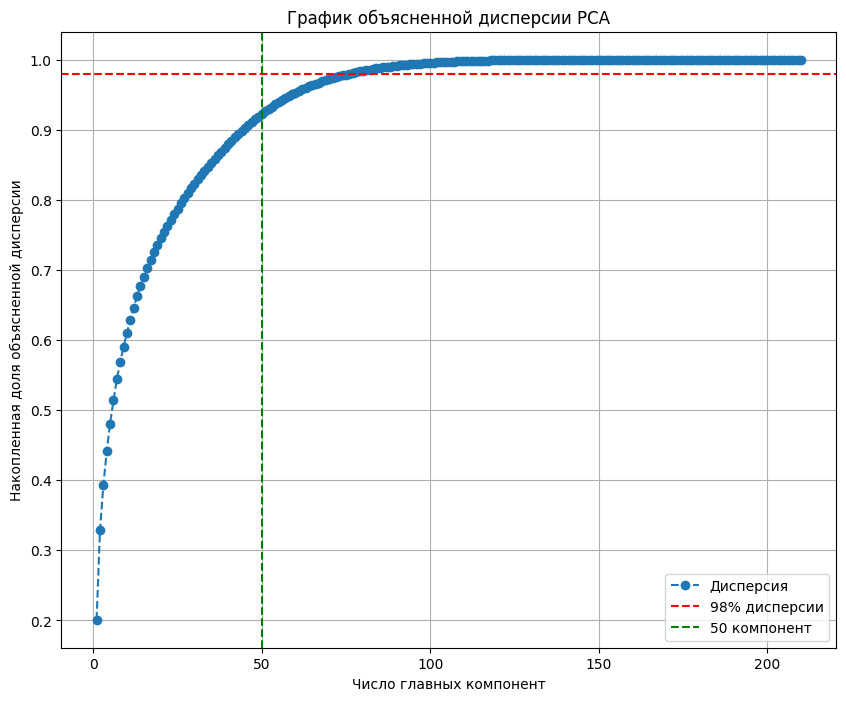

In [372]:
#снижениие размерности - 
from sklearn.preprocessing import StandardScaler


# fit вычисляет параметры, transform преобразует данные

scaler = StandardScaler()
X_new = scaler.fit_transform(drugs_fin.drop(['IC50, mM', 'CC50, mM', 'SI'], axis=1))
#X_new = scaler.fit_transform(drugs_fin_filtered_v2)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit(X_new)

explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 8))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label="Дисперсия")

# Добавляем горизонтальную линию на уровне 0.98
plt.axhline(y=0.98, color='r', linestyle='--', label="98% дисперсии")

# Добавляем вертикальную линию 
plt.axvline(x=50, color='g', linestyle='--', label="50 компонент")

plt.xlabel('Число главных компонент')
plt.ylabel('Накопленная доля объясненной дисперсии')
plt.title('График объясненной дисперсии PCA')
plt.legend()
plt.grid()
plt.show()

In [311]:
n_components = np.argmax(explained_variance_ratio >= 0.98) + 1
print(f'Количество компонентов для объяснения 98% дисперсии: {n_components}')

Количество компонентов для объяснения 98% дисперсии: 76
